# 06 - Incident Prediction Modeling

# Predicción de incidencias logísticas mediante Machine Learning

En este notebook se desarrolla un nuevo problema de clasificación enfocado en la predicción de incidencias logísticas utilizando la variable `tiene_incidencia`.

## Objetivos

- Analizar la distribución de incidencias.
- Entrenar modelos de clasificación.
- Comparar métricas.
- Identificar el mejor modelo.
- Evaluar si el dataset posee capacidad predictiva para detectar riesgos operacionales.

In [17]:
%load_ext kedro.ipython

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,5)


The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


# 1. Carga del dataset

In [18]:
df = catalog.load("dataset_modelo")

df.head()


[05/10/26 19:49:58] INFO     Loading data from dataset_modelo (CSVDataset)...                  ]8;id=16160604;file://C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=16160605;file://C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

,id_envio,fecha_envio,id_ruta,id_vehiculo,peso_kg,volumen_m3,tipo_carga,estado,fecha_entrega,origen,...,km_recorridos,cantidad_incidencias,costo_total_incidencias,tipo_incidencia_principal,tiene_incidencia,dias_entrega,velocidad_promedio_km_h,uso_capacidad_kg,uso_capacidad_m3,entrega_tardia
0,1.0,2023-01-01,39.0,46.0,12675.8,28.48,peligrosa,entregado,2023-01-05,valparaíso,...,17043.0,0.0,0.0,sin incidencia,0.0,4.0,55.047904,1.26758,1.389268,1
1,2.0,NaN,3.0,27.0,13.6,24.93,peligrosa,entregado,2023-01-05,rancagua,...,88004.0,0.0,0.0,sin incidencia,0.0,7.0,36.934783,0.01360,1.128054,1
2,3.0,2023-01-02,73.0,18.0,2536.0,50.55,refrigerada,entregado,NaN,maipú,...,243705.0,0.0,0.0,sin incidencia,0.0,7.0,90.076923,0.12680,1.299486,1
3,4.0,2023-01-03,49.0,45.0,466.0,13.88,peligrosa,en tránsito,2023-01-07,las condes,...,224573.5,1.0,1747372.0,desvío de ruta,1.0,4.0,86.899471,0.46600,0.548617,1
4,5.0,NaN,17.0,36.0,4928.9,0.44,refrigerada,retrasado,2023-01-07,maipú,...,138259.0,0.0,0.0,sin incidencia,0.0,7.0,86.960894,0.98578,0.008961,1


# 2. Exploración de la variable objetivo

In [19]:
df["tiene_incidencia"].value_counts()



tiene_incidencia
0.0    856
1.0    174
Name: count, dtype: int64

In [20]:
df["tiene_incidencia"].value_counts(normalize=True) * 100



tiene_incidencia
0.0    83.106796
1.0    16.893204
Name: proportion, dtype: float64

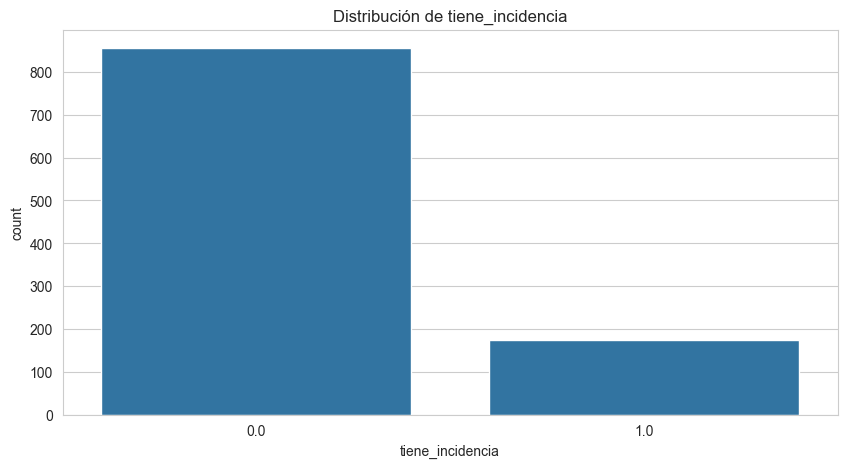

In [21]:
sns.countplot(data=df, x="tiene_incidencia")

plt.title("Distribución de tiene_incidencia")

plt.show()


La distribución de incidencias permitirá identificar si existe desbalance de clases y evaluar si el problema resulta adecuado para clasificación.

# 3. Selección de variables

In [22]:
variables_modelo = [
    "distancia_km",
    "tiempo_estimado_hrs",
    "peso_kg",
    "volumen_m3",
    "capacidad_kg",
    "capacidad_m3",
    "uso_capacidad_kg",
    "uso_capacidad_m3",
    "velocidad_promedio_km_h",
    "tipo_via",
    "tipo_carga",
    "estado_vehiculo"
]

objetivo = "tiene_incidencia"

X = df[variables_modelo]
y = df[objetivo]

print(X.shape)
print(y.shape)


(1030, 12)
(1030,)


# 4. Revisión de nulos

In [23]:
nulos = X.isnull().sum().sort_values(ascending=False)

nulos[nulos > 0]



capacidad_m3           31
estado_vehiculo        31
capacidad_kg           31
distancia_km           28
tiempo_estimado_hrs    28
tipo_via               28
dtype: int64

Los valores nulos serán tratados automáticamente mediante pipelines de Scikit-learn.

# 5. Pipeline de preprocesamiento

In [24]:
variables_numericas = X.select_dtypes(include=np.number).columns.tolist()
variables_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

transformador_numerico = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

transformador_categorico = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocesador = ColumnTransformer([
    ("num", transformador_numerico, variables_numericas),
    ("cat", transformador_categorico, variables_categoricas)
])


# 6. División entrenamiento y prueba

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nDistribución y_train:")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribución y_test:")
print(y_test.value_counts(normalize=True) * 100)


X_train: (824, 12)
X_test: (206, 12)

Distribución y_train:
tiene_incidencia
0.0    83.131068
1.0    16.868932
Name: proportion, dtype: float64

Distribución y_test:
tiene_incidencia
0.0    83.009709
1.0    16.990291
Name: proportion, dtype: float64


# 7. Función de evaluación

In [26]:
def evaluar_modelo(nombre_modelo, modelo, X_train, X_test, y_train, y_test):

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"===== {nombre_modelo} =====")
    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Balanced Accuracy : {balanced_acc:.4f}")
    print(f"Precision         : {precision:.4f}")
    print(f"Recall            : {recall:.4f}")
    print(f"F1-score          : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    matriz = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=matriz)

    disp.plot()

    plt.title(f"Matriz de confusión - {nombre_modelo}")

    plt.show()

    return {
        "modelo": nombre_modelo,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }


# 8. Logistic Regression

===== Logistic Regression =====
Accuracy          : 0.5485
Balanced Accuracy : 0.5463
Precision         : 0.1979
Recall            : 0.5429
F1-score          : 0.2901

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.55      0.67       171
         1.0       0.20      0.54      0.29        35

    accuracy                           0.55       206
   macro avg       0.53      0.55      0.48       206
weighted avg       0.74      0.55      0.60       206



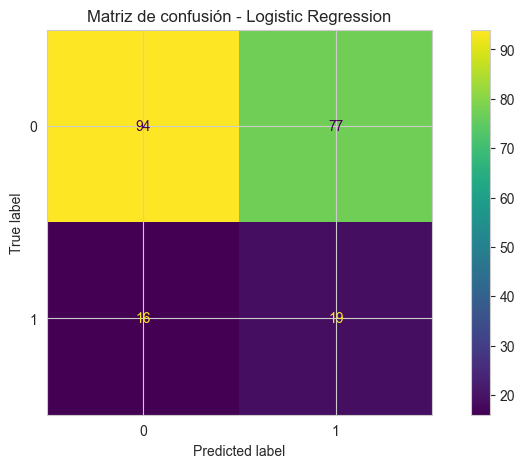

In [27]:
modelo_logistic = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", LogisticRegression(
        random_state=42,
        max_iter=2000,
        class_weight="balanced"
    ))
])

resultado_logistic = evaluar_modelo(
    "Logistic Regression",
    modelo_logistic,
    X_train,
    X_test,
    y_train,
    y_test
)


# 9. Decision Tree

===== Decision Tree =====
Accuracy          : 0.4272
Balanced Accuracy : 0.5527
Precision         : 0.1926
Recall            : 0.7429
F1-score          : 0.3059

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.36      0.51       171
         1.0       0.19      0.74      0.31        35

    accuracy                           0.43       206
   macro avg       0.53      0.55      0.41       206
weighted avg       0.76      0.43      0.48       206



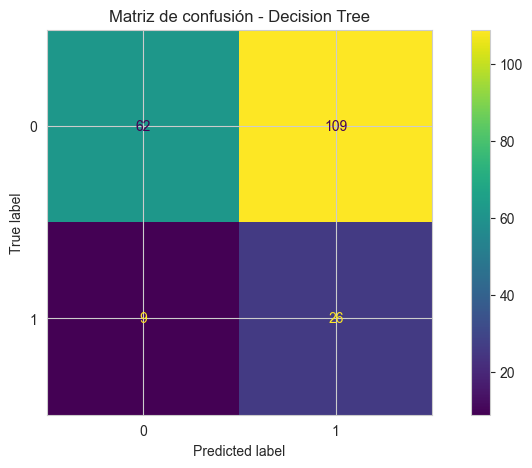

In [28]:
modelo_tree = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", DecisionTreeClassifier(
        random_state=42,
        max_depth=6,
        class_weight="balanced"
    ))
])

resultado_tree = evaluar_modelo(
    "Decision Tree",
    modelo_tree,
    X_train,
    X_test,
    y_train,
    y_test
)


# 10. Random Forest

===== Random Forest =====
Accuracy          : 0.8204
Balanced Accuracy : 0.5055
Precision         : 0.2500
Recall            : 0.0286
F1-score          : 0.0513

Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.98      0.90       171
         1.0       0.25      0.03      0.05        35

    accuracy                           0.82       206
   macro avg       0.54      0.51      0.48       206
weighted avg       0.73      0.82      0.76       206



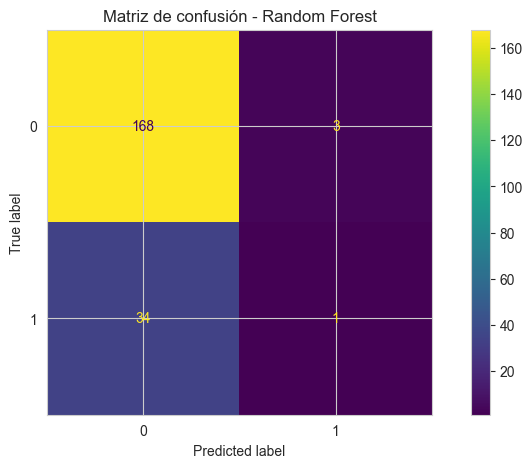

In [29]:
modelo_rf = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=8,
        class_weight="balanced"
    ))
])

resultado_rf = evaluar_modelo(
    "Random Forest",
    modelo_rf,
    X_train,
    X_test,
    y_train,
    y_test
)


# 11. Comparación de modelos

In [30]:
tabla_resultados = pd.DataFrame([
    resultado_logistic,
    resultado_tree,
    resultado_rf
])

tabla_resultados.sort_values(by="f1_score", ascending=False)


,modelo,accuracy,balanced_accuracy,precision,recall,f1_score
1,Decision Tree,0.427184,0.552715,0.192593,0.742857,0.305882
0,Logistic Regression,0.548544,0.546282,0.197917,0.542857,0.290076
2,Random Forest,0.820388,0.505514,0.250000,0.028571,0.051282


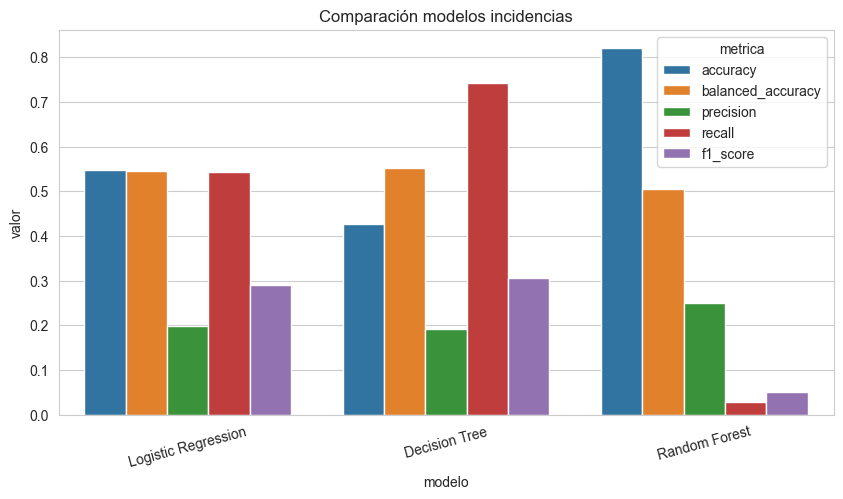

In [31]:
tabla_melt = tabla_resultados.melt(
    id_vars="modelo",
    value_vars=[
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1_score"
    ],
    var_name="metrica",
    value_name="valor"
)

sns.barplot(
    data=tabla_melt,
    x="modelo",
    y="valor",
    hue="metrica"
)

plt.title("Comparación modelos incidencias")

plt.xticks(rotation=15)

plt.show()


# 12. Selección del mejor modelo

In [32]:
mejor_modelo = tabla_resultados.sort_values(
    by="f1_score",
    ascending=False
).iloc[0]

mejor_modelo



modelo               Decision Tree
accuracy                  0.427184
balanced_accuracy         0.552715
precision                 0.192593
recall                    0.742857
f1_score                  0.305882
Name: 1, dtype: object

# 13. Conclusiones

Este notebook permitió incorporar un nuevo problema de clasificación orientado a riesgos operacionales.

La predicción de incidencias resulta relevante desde el punto de vista logístico porque permite anticipar posibles problemas durante la operación.

Las métricas de recall y F1-score serán especialmente importantes debido al posible desbalance de clases.